In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv("/content/dataset_phishing.csv.zip")
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [11]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


In [16]:
df.columns.tolist()

['url',
 'length_url',
 'length_hostname',
 'ip',
 'nb_dots',
 'nb_hyphens',
 'nb_at',
 'nb_qm',
 'nb_and',
 'nb_or',
 'nb_eq',
 'nb_underscore',
 'nb_tilde',
 'nb_percent',
 'nb_slash',
 'nb_star',
 'nb_colon',
 'nb_comma',
 'nb_semicolumn',
 'nb_dollar',
 'nb_space',
 'nb_www',
 'nb_com',
 'nb_dslash',
 'http_in_path',
 'https_token',
 'ratio_digits_url',
 'ratio_digits_host',
 'punycode',
 'port',
 'tld_in_path',
 'tld_in_subdomain',
 'abnormal_subdomain',
 'nb_subdomains',
 'prefix_suffix',
 'random_domain',
 'shortening_service',
 'path_extension',
 'nb_redirection',
 'nb_external_redirection',
 'length_words_raw',
 'char_repeat',
 'shortest_words_raw',
 'shortest_word_host',
 'shortest_word_path',
 'longest_words_raw',
 'longest_word_host',
 'longest_word_path',
 'avg_words_raw',
 'avg_word_host',
 'avg_word_path',
 'phish_hints',
 'domain_in_brand',
 'brand_in_subdomain',
 'brand_in_path',
 'suspecious_tld',
 'statistical_report',
 'nb_hyperlinks',
 'ratio_intHyperlinks',
 'rati

In [21]:
df.shape

(11430, 89)

In [19]:
df.isnull().sum()


,0
url,0
length_url,0
length_hostname,0
ip,0
nb_dots,0
...,...
web_traffic,0
dns_record,0
google_index,0
page_rank,0


In [43]:
df.duplicated().sum()

np.int64(0)

Class distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Phishing %: 50.0%


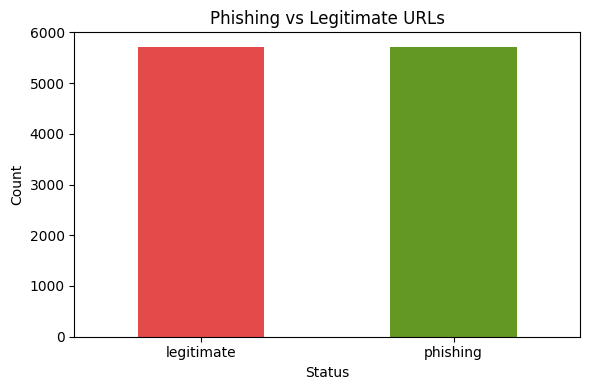

In [22]:
print("Class distribution:")
print(df['status'].value_counts())
print(f"\nPhishing %: {(df['status']=='phishing').mean()*100:.1f}%")

plt.figure(figsize=(6,4))
df['status'].value_counts().plot(kind='bar', color=['#E24B4A','#639922'])
plt.title('Phishing vs Legitimate URLs')
plt.xlabel('Status'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

df['label'] = (df['status'] == 'phishing').astype(int)

X = df.drop(['status', 'label', 'url'], axis=1, errors='ignore')
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 9144
Testing samples:  2286


In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


Accuracy: 96.19%

              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96      1143
    Phishing       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



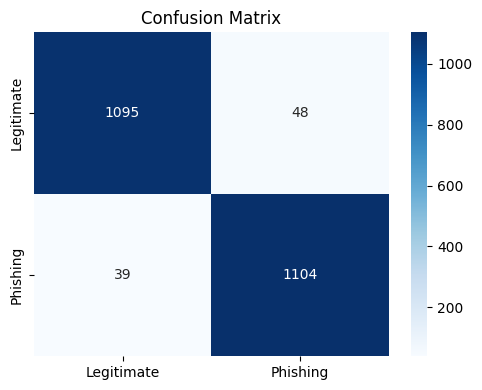

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate','Phishing']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legitimate','Phishing'],
    yticklabels=['Legitimate','Phishing'])
plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()

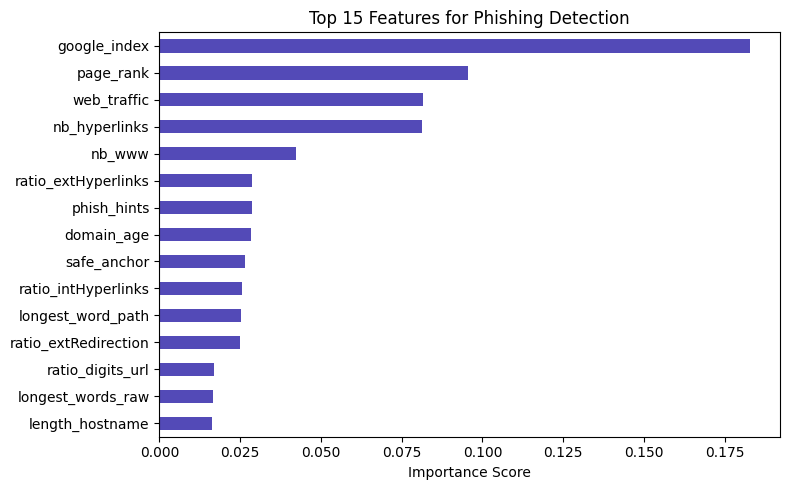

In [31]:
importances = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#534AB7')
plt.title('Top 15 Features for Phishing Detection')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [34]:
def predict_url(url_features: dict):
    """
    Pass a dict of feature values to get a prediction.
    """
    import pandas as pd
    sample = pd.DataFrame([url_features])
    sample = sample.reindex(columns=X.columns, fill_value=0)
    pred = model.predict(sample)[0]
    prob = model.predict_proba(sample)[0][1]

    label = "PHISHING" if pred == 1 else "LEGITIMATE"
    print(f"Verdict:    {label}")
    print(f"Risk Score: {prob*100:.1f}%")
    return label, prob

# --- Test it with a sample from your dataset ---
print("=== Testing on known PHISHING sample ===")
phishing_sample = X_test[y_test == 1].iloc[0].to_dict()
predict_url(phishing_sample)

print()
print("=== Testing on known LEGITIMATE sample ===")
legit_sample = X_test[y_test == 0].iloc[0].to_dict()
predict_url(legit_sample)

=== Testing on known PHISHING sample ===
Verdict:    PHISHING
Risk Score: 95.9%

=== Testing on known LEGITIMATE sample ===
Verdict:    LEGITIMATE
Risk Score: 1.4%


('LEGITIMATE', np.float64(0.014324690778068493))